# Edward Moswane Assignment 14: Ethical AI Analysis and Explainability

# Dataset Preparation

In [ ]:
# Installing required libraries
!pip install fairlearn shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 6.1 MB/s eta 0:00:00


In [ ]:
# Importing signficant libraries for this projects
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular

from fairlearn.metrics import (MetricFrame,selection_rate,false_positive_rate,true_positive_rate)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)

print("All Signficant libraries imported successfully!")

All Signficant libraries imported successfully!


Load the dataset

In [ ]:
# Load the dataset for the assignment (adult dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = ["age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"]

df = pd.read_csv(url,names=columns,na_values="?",skipinitialspace=True)

print("Adult Data Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Adult Data Dataset loaded successfully!
Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Explorinf the Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
#Checking missing value
print("Missing values:")
print(df.isnull().sum())

print("\nIncome distribution:")
print(df["income"].value_counts())

print("\nGender distribution:")
print(df["sex"].value_counts())

Missing values:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Income distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Gender distribution:
sex
Male      21790
Female    10771
Name: count, dtype: int64


In [ ]:
# Removing rows with missing values
df = df.dropna().copy()

# Removing extra spaces from categorical values
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

# Convert income into a binary target
# 1 = income >50K
# 0 = income <=50K
df["income_binary"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1})

print("Cleaned Dataset:", df.shape)
df.head()

Cleaned Dataset: (30162, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
income_binary     0
dtype: int64


selecting features (X) and the target variable (y)

In [ ]:
# Defining the features, target and attribute
target = "income_binary"
sensitive_feature = "sex"

# Features used by the model
features = ["age","workclass","education",
    "education_num","marital_status","occupation",
    "relationship","race","capital_gain","capital_loss",
    "hours_per_week","native_country"]

X = df[features]
y = df[target]

# Sensitive attribute for fairness analysis
sensitive = df[sensitive_feature]

In [ ]:
print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("Sensitive Attribute:", sensitive_feature)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nSensitive Attribute Distribution:")
print(sensitive.value_counts())

Features (X): (30162, 12)
Target (y): (30162,)
Sensitive Attribute: sex

Target Distribution:
income_binary
0    22654
1     7508
Name: count, dtype: int64

Sensitive Attribute Distribution:
sex
Male      20380
Female     9782
Name: count, dtype: int64


# Model Training and Evaluation:

In [ ]:
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,y,sensitive,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24129
Testing samples: 6033


Preprocessing the features in the dataset

In [ ]:
# Identifying numerical and categorical columns
numeric_features = ["age",
    "fnlwgt" if "fnlwgt" in features else "age",
    "education_num","capital_gain","capital_loss","hours_per_week"]

# Removing duplicates
numeric_features = list(dict.fromkeys(numeric_features))

categorical_features = [
    column for column in features
    if column not in numeric_features]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[("numeric",StandardScaler(),numeric_features),

        ("categorical",OneHotEncoder(handle_unknown="ignore",
                sparse_output=False),categorical_features)])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


Train a logistic regression model using scikit-learn.

In [ ]:
# Creating Logistic Regression model

model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000,random_state=42))])

# Training the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Make predictions

In [ ]:
# Making predictions on the test set

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [1 0 1 0 1 1 1 0 0 1]


Evaluate model performance using accuracy, confusion matrices, and classification reports.

In [ ]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.8457
Model Accuracy: 84.57%


Classification Report

In [ ]:
print("________________Classification Report______________")

print(classification_report(y_test,y_pred,target_names=["Income <=50K", "Income >50K"]))

________________Classification Report______________
              precision    recall  f1-score   support

Income <=50K       0.88      0.93      0.90      4531
 Income >50K       0.73      0.60      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.80      0.76      0.78      6033
weighted avg       0.84      0.85      0.84      6033



Confusion matrix

Confusion Matrix:
[[4197  334]
 [ 597  905]]


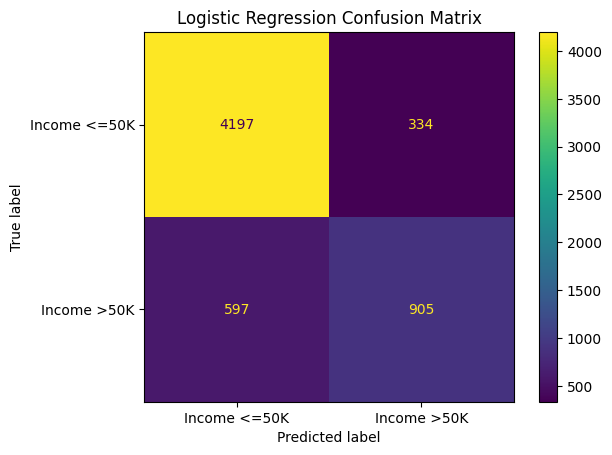

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Income <=50K", "Income >50K"]).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Fairness Analysis

In [ ]:
# Fairness metrics by gender
fairness_metrics = {
    "Selection Rate": selection_rate,
    "False Positive Rate": false_positive_rate,
    "True Positive Rate": true_positive_rate}

metric_frame = MetricFrame(metrics=fairness_metrics,y_true=y_test,y_pred=y_pred,sensitive_features=sensitive_test)

print("__________________Fairness Metrics by Gender_______________________________")
print(metric_frame.by_group)

__________________Fairness Metrics by Gender_______________________________
        Selection Rate  False Positive Rate  True Positive Rate
sex                                                            
Female        0.091972             0.030006            0.548936
Male          0.260271             0.100786            0.612470


Total Fairness Metrics

In [ ]:
print("___________________Total Fairness Metrics____________________")
print(metric_frame.overall)

___________________Total Fairness Metrics____________________
Selection Rate         0.205370
False Positive Rate    0.073714
True Positive Rate     0.602530
dtype: float64


Visualize fairness metrics using bar plots for better interpretability.


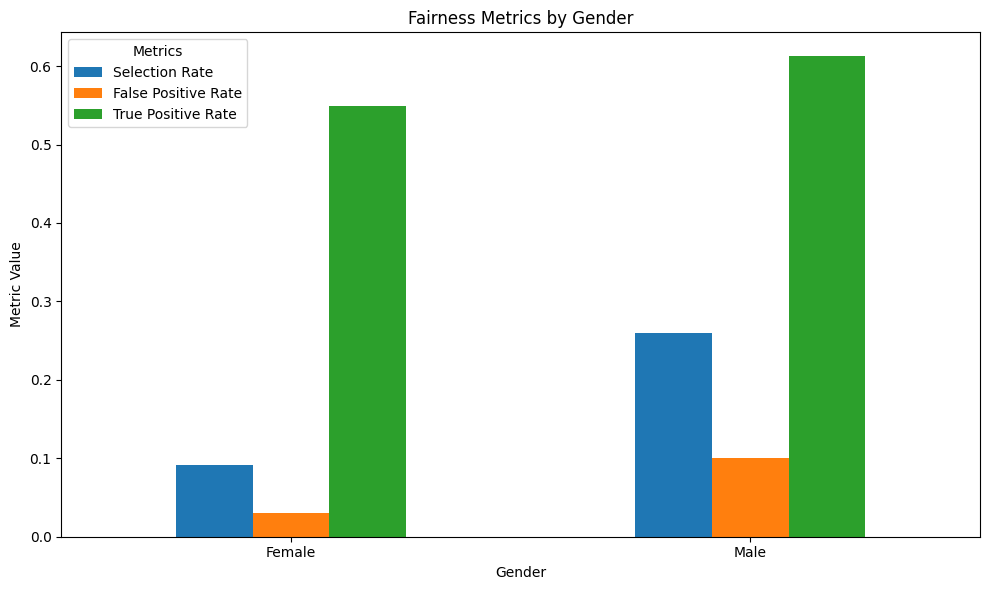

In [ ]:
# Plot of fairness metrics by gender
metric_frame.by_group.plot(kind="bar",figsize=(10, 6))

plt.title("Fairness Metrics by Gender")
plt.xlabel("Gender")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Explainability Analysis

 Creating and applying SHAP (SHapley Additive exPlanations) for global and local explainability

In [ ]:
# Transforming test data for SHAP(SHapley Additive exPlanations)

X_test_transformed = model.named_steps["preprocessor"].transform(X_test)

classifier = model.named_steps["classifier"]

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 101


In [ ]:
# Creating Explainer

explainer = shap.LinearExplainer(classifier,X_test_transformed)

shap_values = explainer(X_test_transformed)

print("The SHAP values calculated successfully!")

The SHAP values calculated successfully!


Generate SHAP summary plots to highlight important features globally.

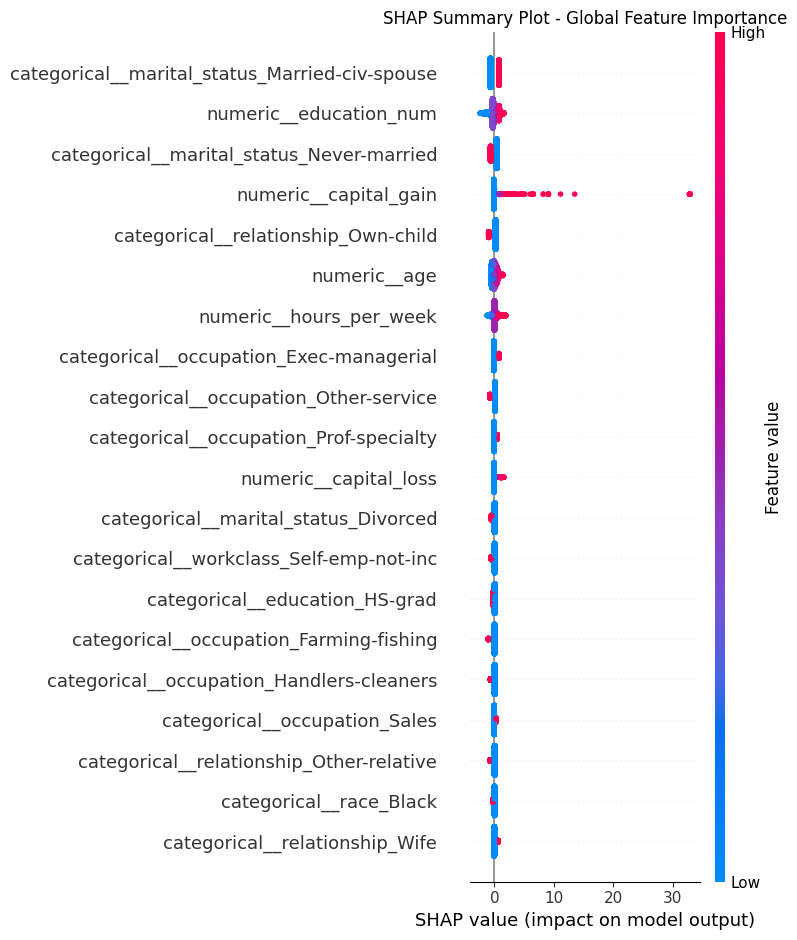

In [ ]:
# SHAP Summary Plot
shap.summary_plot(shap_values,X_test_transformed,feature_names=feature_names,show=False)

plt.title("SHAP Summary Plot - Global Feature Importance")
plt.tight_layout()
plt.show()

Use SHAP waterfall plots to explain individual predictions locally.

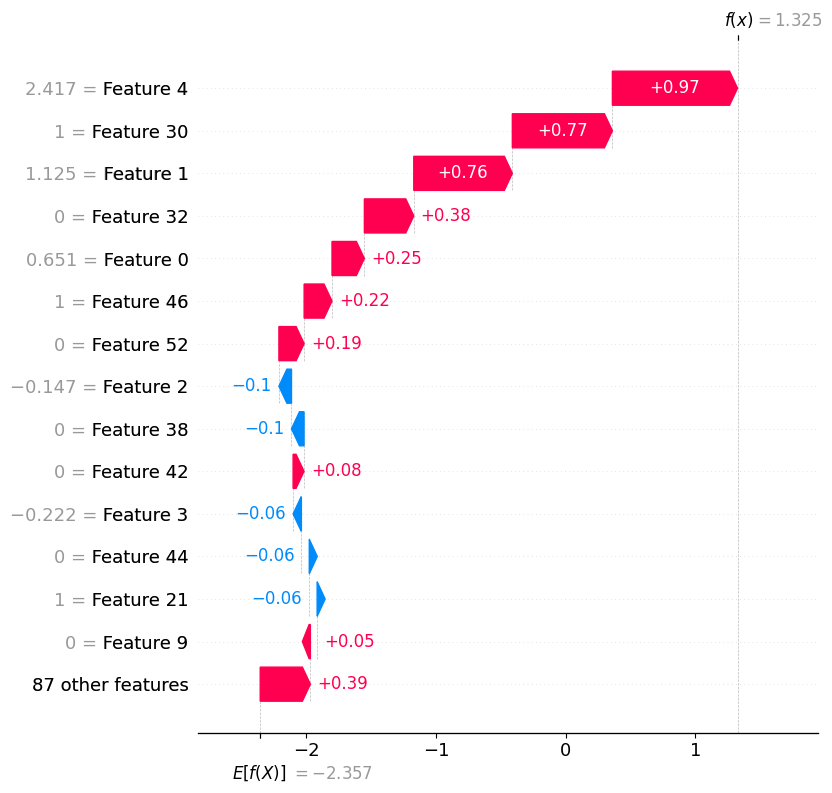

In [ ]:
# SHAP Waterfall Plot for one individual prediction
sample_index = 0

shap.plots.waterfall(shap_values[sample_index],max_display=15)

LIME Explainability: Using LIME (Local Interpretable Model-agnostic Explanations) for detailed interpretation of individual predictions.

In [ ]:
# Creating LIME explainer

lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_test_transformed,
    feature_names=feature_names,class_names=["Income <=50K", "Income >50K"],mode="classification",
    random_state=42)

print("LIME explainer is created successfully!")

LIME explainer is created successfully!


In [ ]:
# LIME explanation for one individual prediction

lime_exp = lime_explainer.explain_instance(X_test_transformed[0],classifier.predict_proba,num_features=10)

lime_exp.show_in_notebook(show_table=True)

# Ethical Considerations

Ethical AI is important because models can learn and reprodcuce bias from the data. For this assignment, gender was used to check fairness between groups. The outcomes indicated some signficanct differences. It is importand to ensure the model is reviewd and being implemented to the real world. Advice is to keep humans invlove to eleminate the data biasness.

# Ethical Considerations
Ethical AI is important because machine learning models can reproduce or increase biases that exist in the data used to train them. In thisb assignment project, gender was treated as a sensitive attribute and fairness metrics were used to compare model performance between groups. Possible improvements include using more representative data, regularly monitoring fairness metrics, testing different modeling approaches, reducing unnecessary bias in the training data, and keeping humans involved in important decisions.


# Fairness Findings

The fairness analysis indicated a signficant differences between female and male groups. The selection rate was 9.20% for females and 26.03% for males, indicating that the model predicted an income above $50K more often for males. The false positive rate was 3.00% for females compared with 10.08% for males. The true positive rate was 54.89% for females and 61.25% for males. These outcomes suggest that the model does not produce identical outcomes across the two groups. The model should always be reviewed for potential fairness concerns before being implemented into the busniness for insights.

# Conclusion
The assignment demostrated how Logistic Regression can be evaluated for accuracy, fairness, and explainability. Fairlearn compared the model's results across gender groups. SHAP and LIME improved the model's predictions.  SHAP showed an overview significance of features with greatest influence on model prediction

# ColabLink

https://colab.research.google.com/drive/1zXTkto4EGpXF6v0pUodO8TG-fST499Pw?usp=sharing

GitHub

https://github.com/Edward-Moswane/AI_Assignments/blob/main/Lesson_14_assignment.ipynb